# P1b — exact local SSE 대 tabular Q-learning

묻는 것: **어떤 계산 조건에서 exact local SSE 계산이 RL 근사보다 나은가.**
알고리즘 우열이 아니라 조건별 선택 문제다.

이 노트북은 디스크에 저장된 실측치를 읽어 표와 그림으로 정리한다. 솔버를
다시 돌리지 않는다 — Cartesian 축의 5 m 한 점만 5.9시간이다.

| 축 | 측정 대상 | 점 개수 |
|---|---|---|
| Cartesian `dx` | full local SSE (방어자 탐색 전체) | 6 |
| heading `dpsi` | 고정 `d`에서의 best response 1회 | 4 |
| Cartesian `dx` (참고) | 고정 `d`에서의 best response 1회 | 7 |

두 축의 측정 대상이 다르다. 헤딩을 full SSE로 훑은 데이터가 없어서지,
의도한 설계가 아니다. 조건 전체는 `r2_discretization_sweeps/README.md` 참조.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import (
    FuncFormatter, LogLocator, MaxNLocator, NullFormatter,
)

from P1b_sweep_figures import SERIES, _power_law

# P1b_sweep_figures pins the Agg backend so it can write PNGs headless;
# undo that here or every figure below renders to nothing.
%matplotlib inline

DATA = Path('r2_discretization_sweeps/data')

spatial_sse = json.loads((DATA / 'spatial_sweep_full_sse.json').read_text('utf-8'))
heading = json.loads((DATA / 'heading_sweep_fixed_defender.json').read_text('utf-8'))
spatial_fixed = json.loads(
    (DATA / 'spatial_sweep_fixed_defender.json').read_text('utf-8')
)

print(f'{len(spatial_sse)} full-SSE points, {len(heading)} heading points, '
      f'{len(spatial_fixed)} fixed-Defender points')


6 full-SSE points, 4 heading points, 7 fixed-Defender points


## 1. 그림 — 이산화 축 대 계산 시간

세 계열만 그린다. 적합 곡선은 넣지 않는다.

- **Exact, total** — 네 단계 전부와 탐색 제어
- **Q-learning, training** / **Q-learning, query** — 둘을 나누는 이유는
  증가분이 거의 전부 training 쪽에 있고 query는 평평하기 때문이다.
  합쳐 그리면 그 차이가 가려진다.

exact 쪽은 Bellman 단계만이 아니라 **총합**이다. RL의 query가 같은 LOS·후보
기하를 이미 포함하므로, 그 고정 비용을 한쪽에만 물리면 exact가 과소 표시된다.


In [2]:
def axis_figure(records, key, title, x_title, *, log=True, ax=None):
    """Redraw one sweep axis inline, on the same terms as the saved PNG."""
    rows = sorted(records, key=lambda r: r[key])
    x = np.asarray([r[key] for r in rows], dtype=float)
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 4.6), dpi=110)
    for name, field, colour, marker, dash in SERIES:
        y = np.asarray([r[field] for r in rows], dtype=float)
        ax.plot(x, y, marker=marker, linestyle=dash, color=colour,
                markersize=6, linewidth=1.6, label=name)
    if log:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xticks(x); ax.set_xticklabels([f'{v:g}' for v in x])
        ax.xaxis.set_minor_locator(LogLocator(subs='all'))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _p: f'{v:g}'))
        ax.yaxis.set_minor_formatter(NullFormatter())
    else:
        ax.set_xlim(0.0, float(x.max()) * 1.05); ax.set_ylim(bottom=0.0)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8, steps=[1, 2, 2.5, 5, 10]))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _p: f'{v:g}'))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _p: f'{v:,.0f}'))
    ax.set_xlabel(x_title); ax.set_ylabel('computation time [s]')
    ax.set_title(title, fontsize=11)
    ax.grid(True, which='major', color='#DDDDDD', linewidth=0.7)
    ax.grid(True, which='minor', color='#F0F0F0', linewidth=0.5)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.legend(loc='upper right', frameon=True, framealpha=0.9,
              edgecolor='none', fontsize=9)
    return ax


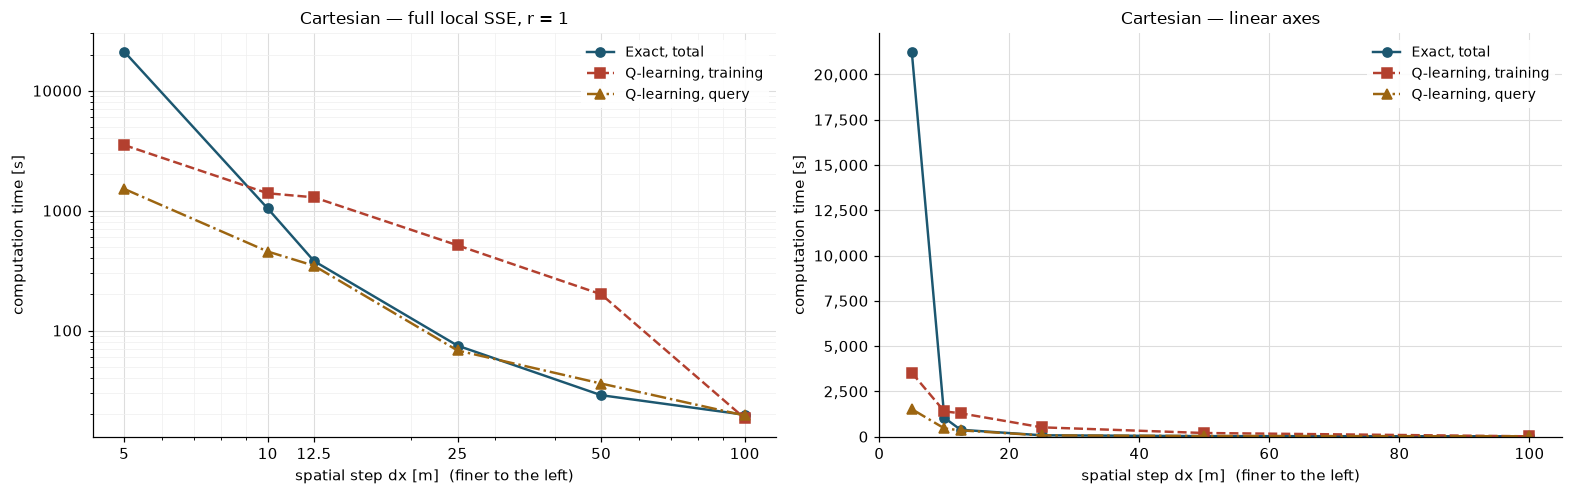

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(14.4, 4.6), dpi=110)
axis_figure(spatial_sse, 'dx_m',
            'Cartesian — full local SSE, r = 1',
            'spatial step dx [m]  (finer to the left)', ax=axes[0])
axis_figure(spatial_sse, 'dx_m',
            'Cartesian — linear axes',
            'spatial step dx [m]  (finer to the left)', log=False, ax=axes[1])
figure.tight_layout()
plt.show()


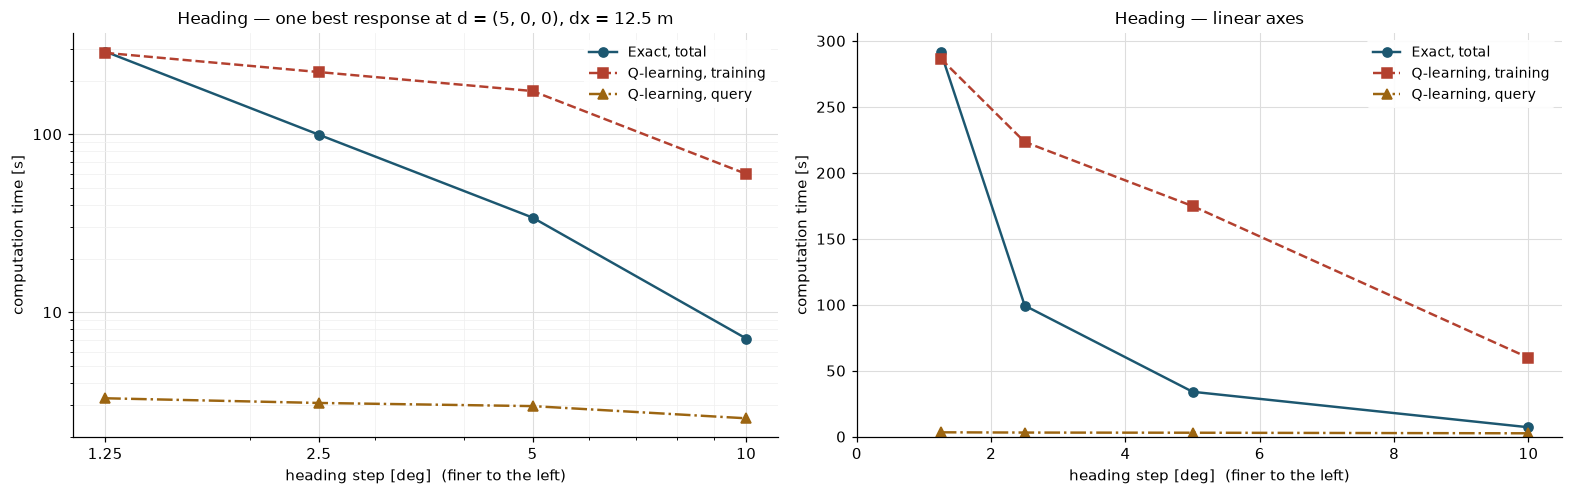

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(14.4, 4.6), dpi=110)
axis_figure(heading, 'dpsi_deg',
            'Heading — one best response at d = (5, 0, 0), dx = 12.5 m',
            'heading step [deg]  (finer to the left)', ax=axes[0])
axis_figure(heading, 'dpsi_deg',
            'Heading — linear axes',
            'heading step [deg]  (finer to the left)', log=False, ax=axes[1])
figure.tight_layout()
plt.show()


## 2. Cartesian 축 — full local SSE 실측표


In [5]:
head = (f"{'dx':>7}{'exact':>10}{'Bellman':>10}{'ev':>4}{'it':>4}"
        f"{'RL':>10}{'train':>9}{'query':>9}{'ev':>4}{'RL/exact':>10}")
print(head)
print('-' * len(head))
for r in sorted(spatial_sse, key=lambda r: -r['dx_m']):
    print(f"{r['dx_m']:>6g}m{r['exact_s']:>10.1f}{r['exact_stage3_bellman_s']:>10.1f}"
          f"{r['exact_evaluations']:>4}{r['exact_iterations']:>4}"
          f"{r['rl_s']:>10.1f}{r['rl_train_s']:>9.1f}{r['rl_query_s']:>9.1f}"
          f"{r['rl_evaluations']:>4}{r['rl_s'] / r['exact_s']:>9.2f}x")


     dx     exact   Bellman  ev  it        RL    train    query  ev  RL/exact
-----------------------------------------------------------------------------
   100m      19.8       1.8   9   1      38.1     18.5     19.6   9     1.92x
    50m      28.9       8.9   9   1     236.6    200.5     36.1  14     8.19x
    25m      74.8      48.5  12   2     581.6    513.5     68.1  12     7.78x
  12.5m     379.9     353.4  12   2    1637.5   1290.5    347.1  14     4.31x
    10m    1041.9     999.3  18   4    1850.3   1394.5    455.7  14     1.78x
     5m   21221.3   21080.0  48  11    5040.6   3523.0   1517.6  14     0.24x


### 교차점

exact가 RL보다 비싸지는 지점이 이 실험의 답이다. 아래 셀이 그 위치를
실측 두 점 사이로 좁힌다.


In [6]:
rows = sorted(spatial_sse, key=lambda r: -r['dx_m'])
ratios = [(r['dx_m'], r['rl_s'] / r['exact_s']) for r in rows]
for (coarse, a), (fine, b) in zip(ratios, ratios[1:]):
    if (a - 1.0) * (b - 1.0) < 0:
        print(f'crossing between dx = {coarse:g} m (RL/exact {a:.2f}x) '
              f'and dx = {fine:g} m (RL/exact {b:.2f}x)')
print()
print('Bellman share of exact total:')
for r in rows:
    share = r['exact_stage3_bellman_s'] / r['exact_s']
    print(f"  dx = {r['dx_m']:>5g} m   {share:>6.1%}"
          f"   fixed-cost stages {r['exact_s'] - r['exact_stage3_bellman_s']:>7.1f} s")


crossing between dx = 10 m (RL/exact 1.78x) and dx = 5 m (RL/exact 0.24x)

Bellman share of exact total:
  dx =   100 m     9.1%   fixed-cost stages    18.0 s
  dx =    50 m    30.9%   fixed-cost stages    19.9 s
  dx =    25 m    64.8%   fixed-cost stages    26.3 s
  dx =  12.5 m    93.0%   fixed-cost stages    26.5 s
  dx =    10 m    95.9%   fixed-cost stages    42.6 s
  dx =     5 m    99.3%   fixed-cost stages   141.3 s


### 탐색 길이가 곱해지는 부분

full SSE의 비용은 best response 1회 비용에 방어자 평가 횟수를 곱한 것이다.
두 데이터셋을 나란히 두면 그 곱이 보인다 — 그리고 exact의 평가 횟수만
해상도에 따라 늘어난다.


In [7]:
fixed = {r['dx_m']: r for r in spatial_fixed}
head = (f"{'dx':>7}{'1 solve':>10}{'x ev':>6}{'= expected':>12}"
        f"{'measured':>11}{'exact ev':>10}{'RL ev':>7}")
print(head)
print('-' * len(head))
for r in sorted(spatial_sse, key=lambda x: -x['dx_m']):
    one = fixed.get(r['dx_m'])
    if one is None:
        continue
    expected = one['exact_stage3_bellman_s'] * r['exact_evaluations']
    print(f"{r['dx_m']:>6g}m{one['exact_stage3_bellman_s']:>10.1f}"
          f"{r['exact_evaluations']:>6}{expected:>12.1f}"
          f"{r['exact_stage3_bellman_s']:>11.1f}"
          f"{r['exact_evaluations']:>10}{r['rl_evaluations']:>7}")


     dx   1 solve  x ev  = expected   measured  exact ev  RL ev
---------------------------------------------------------------
   100m       0.2     9         1.7        1.8         9      9
    50m       0.9     9         8.0        8.9         9     14
    25m       4.2    12        50.5       48.5        12     12
  12.5m      28.1    12       337.7      353.4        12     14
    10m      52.2    18       939.3      999.3        18     14
     5m     442.7    48     21250.6    21080.0        48     14


## 3. Heading 축 — 고정 `d`, best response 1회

`dpsi`를 절반으로 줄이면 `A`가 2배, `N_S`가 2배이므로 `N_S*A`는 4배가 된다.


In [8]:
head = (f"{'dpsi':>8}{'A':>5}{'N_S':>14}{'N_S*A':>17}{'RSS MiB':>9}"
        f"{'exact':>9}{'Bellman':>9}{'RL':>9}{'train':>9}{'query':>8}{'acc':>8}")
print(head)
print('-' * len(head))
for r in sorted(heading, key=lambda r: -r['dpsi_deg']):
    print(f"{r['dpsi_deg']:>6g}dg{r['A']:>5}{r['N_S']:>14,}{r['N_S_times_A']:>17,}"
          f"{r['rss_peak_MiB']:>9.0f}{r['exact_s']:>9.2f}"
          f"{r['exact_stage3_bellman_s']:>9.2f}{r['rl_s']:>9.2f}"
          f"{r['rl_train_s']:>9.2f}{r['rl_query_s']:>8.2f}"
          f"{r['attacker_accuracy']:>8.4f}")
print()
print('step-to-step growth, coarse -> fine:')
rows = sorted(heading, key=lambda r: -r['dpsi_deg'])
for a, b in zip(rows, rows[1:]):
    print(f"  {a['dpsi_deg']:>5g} -> {b['dpsi_deg']:<5g} deg"
          f"   N_S*A x{b['N_S_times_A'] / a['N_S_times_A']:.2f}"
          f"   Bellman x{b['exact_stage3_bellman_s'] / a['exact_stage3_bellman_s']:.2f}"
          f"   RL train x{b['rl_train_s'] / a['rl_train_s']:.2f}")


    dpsi    A           N_S            N_S*A  RSS MiB    exact  Bellman       RL    train   query     acc
---------------------------------------------------------------------------------------------------------
    10dg   36    12,376,260      445,545,360      451     7.11     4.89    62.35    59.81    2.53  0.9503
     5dg   72    24,752,520    1,782,181,440     2075    34.00    31.55   177.73   174.76    2.97  0.9351
   2.5dg  144    49,505,040    7,128,725,760     3477    99.35    96.62   226.48   223.39    3.09  0.9431
  1.25dg  288    99,010,080   28,514,903,040     5066   291.42   287.30   289.80   286.52    3.28  0.9618

step-to-step growth, coarse -> fine:
     10 -> 5     deg   N_S*A x4.00   Bellman x6.45   RL train x2.92
      5 -> 2.5   deg   N_S*A x4.00   Bellman x3.06   RL train x1.28
    2.5 -> 1.25  deg   N_S*A x4.00   Bellman x2.97   RL train x1.28


### 정확도

`attacker_accuracy`는 **같은 상대**에 대해서만 잰다. 서로 다른 `d`에서 나온
`J_A`를 비교하면 값이 뒤집혀 의미를 잃는다.

```
attacker_accuracy = J_A_exact(학습자가 고른 d에서) / J_A_learned   in (0, 1]
defender_accuracy = true J_D(학습자의 d에서)      / J_D_exact(d*)  in (0, 1]
```

`RL_threshold = 0.9`이고 두 값 모두 넘겨야 통과다.


In [9]:
RL_THRESHOLD = 0.9
values = [r['attacker_accuracy'] for r in heading]
print(f'heading axis attacker_accuracy: min {min(values):.4f}  max {max(values):.4f}'
      f'  -> threshold {RL_THRESHOLD} ' + ('met at every step' if min(values) >= RL_THRESHOLD
                                          else 'MISSED somewhere'))
print()
print('full SSE — did the learner land on the same d* as exact?')
for r in sorted(spatial_sse, key=lambda r: -r['dx_m']):
    same = r['exact_sensor_map'] == r['rl_sensor_map']
    ratio = r['rl_J_D'] / r['exact_J_D']
    print(f"  dx = {r['dx_m']:>5g} m   exact d* {tuple(round(v, 3) for v in r['exact_sensor_map'][:2])}"
          f"   RL d* {tuple(round(v, 3) for v in r['rl_sensor_map'][:2])}"
          f"   {'same' if same else 'differs'}   believed J_D ratio {ratio:.4f}")


heading axis attacker_accuracy: min 0.9351  max 0.9618  -> threshold 0.9 met at every step

full SSE — did the learner land on the same d* as exact?
  dx =   100 m   exact d* (5.0, 0.0)   RL d* (5.0, 0.0)   same   believed J_D ratio 1.0000
  dx =    50 m   exact d* (5.0, 0.0)   RL d* (5.5, -0.5)   differs   believed J_D ratio 1.8490
  dx =    25 m   exact d* (4.75, 0.0)   RL d* (4.75, 0.0)   same   believed J_D ratio 1.2303
  dx =  12.5 m   exact d* (4.875, 0.0)   RL d* (5.125, 0.125)   differs   believed J_D ratio 1.2036
  dx =    10 m   exact d* (5.3, 0.0)   RL d* (5.1, -0.1)   differs   believed J_D ratio 1.2390
  dx =     5 m   exact d* (5.5, -0.1)   RL d* (5.05, -0.05)   differs   believed J_D ratio 1.3676


## 4. 살아 있는 실행 — 100 m 격자 한 번

API 확인용이다. 100 m에서 full local SSE는 exact 약 20 s, RL 약 40 s다.
**더 세밀한 격자로 바꾸지 말 것** — 5 m는 exact 5.9시간, RL 1.4시간이다.


In [10]:
from time import perf_counter

from P1b_condition import ComputationCondition, build_scene
from P1b_Exact_Local_SSE import exact_local_sse
from P1b_RL_approximation import QLearningConfig, rl_local_sse

CONDITION = ComputationCondition(
    spatial_resolution_m=100.0,   # dx = dy = dh
    heading_spacing_deg=5.0,
    r_neighbor=1,                 # Chebyshev radius on the Defender grid
    terrain_category='centered_cube_half_height',
)
CONFIG = QLearningConfig(episodes=20000, seed=0)

scene = build_scene(CONDITION)
print(CONDITION.label)
for key, value in scene.sizes().items():
    print(f'  {key:<24} {value:,}' if isinstance(value, int)
          else f'  {key:<24} {value}')


dx=100m dpsi=5deg r=1
  N_x                      17
  N_y                      9
  N_h                      6
  N_psi                    72
  N_S_cart                 66,096
  N_S_goal_reachable       39,563
  A                        72
  N_D                      49
  neighbourhood_size       9


In [11]:
started = perf_counter()
exact = exact_local_sse(scene)
exact_wall = perf_counter() - started

started = perf_counter()
learned = rl_local_sse(scene, CONFIG, warm_start_episodes=4000)
learned_wall = perf_counter() - started

print(f"{'':<26}{'exact':>26}{'Q-learning':>26}")
print('-' * 78)
rows = [
    ('wall [s]', exact_wall, learned_wall),
    ('unique evaluations', exact.unique_evaluations, learned.unique_evaluations),
    ('search iterations', exact.iterations, learned.iterations),
    ('selected action id', exact.selected_action_id, learned.selected_action_id),
    ('J_D', exact.detection_probability, learned.detection_probability),
    ('J_A', exact.attacker_objective, learned.attacker_objective),
    ('termination', exact.termination_status, learned.termination_status),
]
for label, a, b in rows:
    fa = f'{a:.6f}' if isinstance(a, float) else str(a)
    fb = f'{b:.6f}' if isinstance(b, float) else str(b)
    print(f'{label:<26}{fa:>26}{fb:>26}')
print('-' * 78)
print('same d*:', exact.selected_action_id == learned.selected_action_id)
print()
print('exact timing :', {k: round(v, 2) for k, v in exact.timing.items()})
print('learned timing:', {k: round(v, 2) for k, v in learned.timing.items()})
print('local_sse_verified:', learned.local_sse_verified)


                                               exact                Q-learning
------------------------------------------------------------------------------
wall [s]                                   21.552172                 35.518089
unique evaluations                                 9                         9
search iterations                                  1                         1
selected action id                                26                        26
J_D                                         0.034293                  0.034293
J_A                                         0.190754                  0.190754
termination                      certified_local_sse     approximate_local_sse
------------------------------------------------------------------------------
same d*: True

exact timing : {'T_stage1_los_s': 8.06, 'T_stage2_filter_s': 11.3, 'T_stage3_bellman_s': 1.97, 'T_stage4_powered_s': 0.22, 'T_best_response_sum_s': 21.55, 'T_search_control_s': 0.0, 'T_total_s': 

## 해석 경계

- **두 축의 측정 대상이 다르다.** Cartesian은 방어자 탐색 전체, heading은
  고정 `d`에서의 1회 해다. 두 그림의 y값을 서로 비교하면 안 된다.
- **반복 1회, 시드 1개.** 분산 추정치가 없다. 두 계열이 가까운 구간
  (5 m 부근, 1.25 deg)의 순서는 재현성이 확인되지 않았다.
- **Cartesian의 exact 시간은 backfill 재실행분**이고 RL 시간은 원 실행분이다.
  exact 솔버는 결정론적이고 목적값이 일치함을 확인한 뒤 기록했지만, 벽시계
  시간은 실행마다 -7.7% ~ +5.7% 차이가 났다.
- **`r` 축 그림은 없다.** 부분 데이터만 있고 고정 `dx`에서의 계열이 없다.
- **RL 결과에 exactness 인증을 붙이지 않는다** (`local_sse_verified=False`).
  근사해이고, 그렇게 보고한다.
- **지형 1개에서만 측정했다** (`centered_cube_half_height`).
- 찾은 `d*`는 전부 x = 4.75 ~ 5.50 구간에 있다. 50 m에서 따로 재 본
  d = (7, 0)의 `J_D`는 0.216615로 (5, 0)의 0.025019보다 8.7배 크다. 즉 여기
  보고된 `J_D`는 r = 1 등반이 벗어나지 못한 이웃의 값이지, 영역 최적이 아니다.
